In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
anemia=pd.read_csv("anemia.csv")

In [20]:
anemia.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [21]:
anemia.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


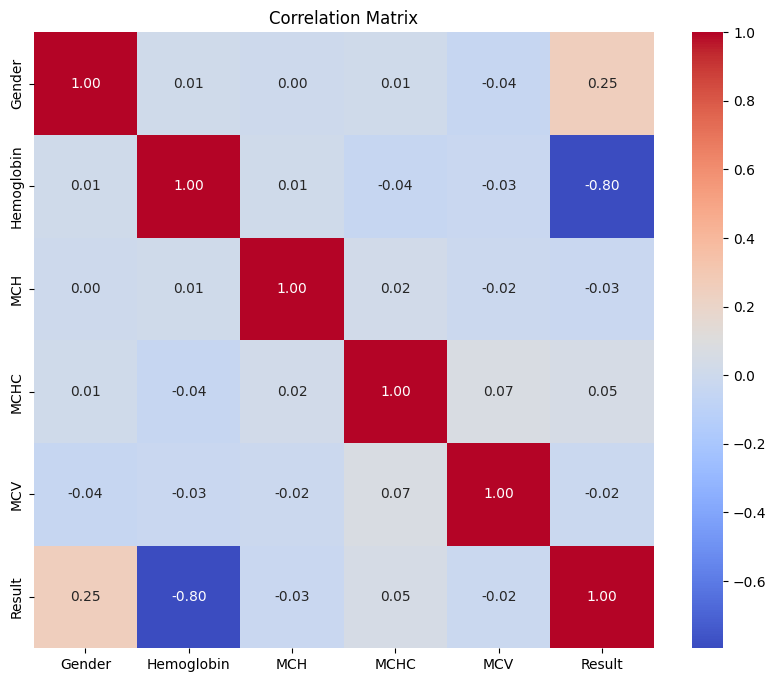

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(anemia.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [23]:
diabetes=pd.read_csv("diabetes_prediction_dataset.csv")

In [24]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [25]:
diabetes.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [27]:
print(anemia.isnull().sum())

Gender        0
Hemoglobin    0
MCH           0
MCHC          0
MCV           0
Result        0
dtype: int64


In [28]:
print(diabetes.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


# feature selection

Here in anemia dataset i need only
 Hemoglobin,
 MCH,
 MCHC,
 MCV,
 Result 
these values only

Here in diabetes datset i need only bmi ,blood_glucose_level ,HbA1c_level ,diabetes

## In anemia

In [29]:
anemia = anemia.drop(columns=["Gender"])

In [30]:
anemia.head()

,Hemoglobin,MCH,MCHC,MCV,Result
0,14.9,22.7,29.1,83.7,0
1,15.9,25.4,28.3,72.0,0
2,9.0,21.5,29.6,71.2,1
3,14.9,16.0,31.4,87.5,0
4,14.7,22.0,28.2,99.5,0


## in diabetes

In [31]:
diabetes = diabetes.drop(columns=["gender","smoking_history"])
diabetes.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0


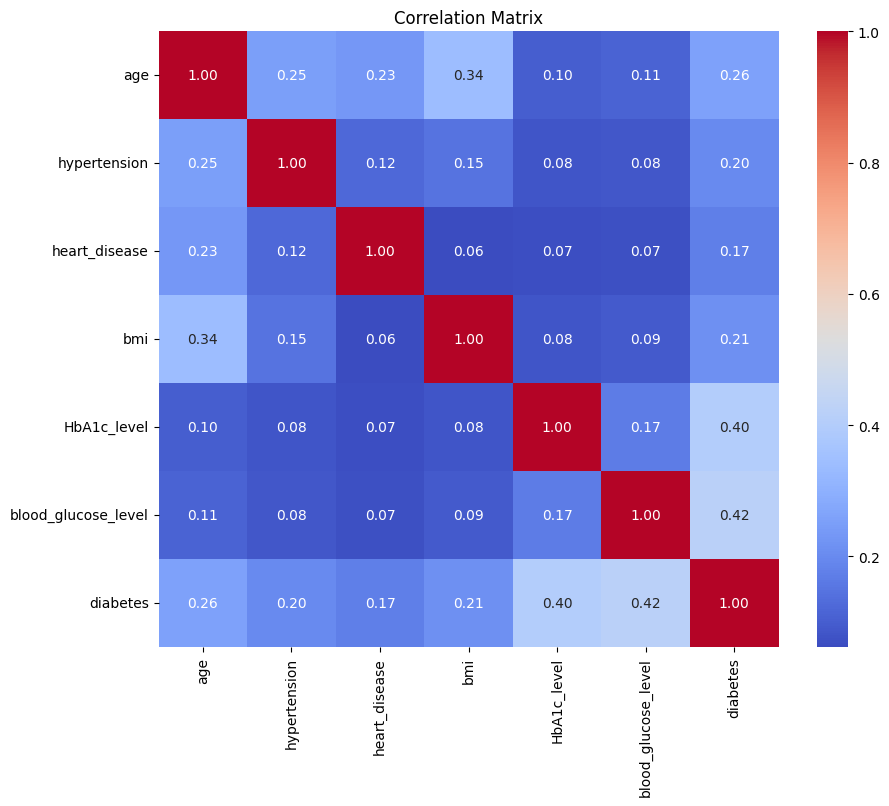

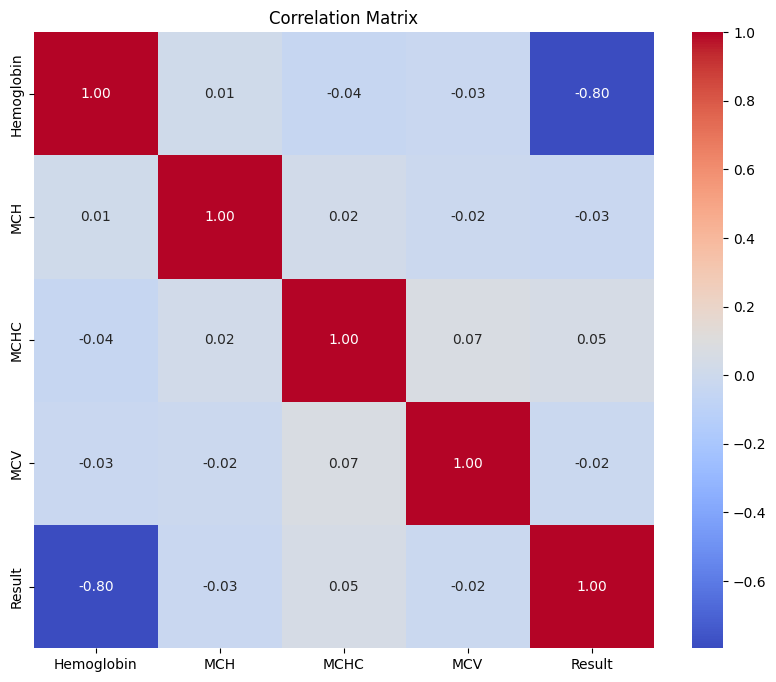

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(anemia.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
## diabetes
x_diabetes = diabetes.drop('diabetes', axis=1) ## independent
y_diabetes = diabetes['diabetes'] ## dependent
## anemia
x_anemia = anemia.drop('Result', axis=1) ## independen
y_anemia = anemia['Result'] ## dependent

In [77]:
from sklearn.model_selection import train_test_split
x_train_anemia,x_test_anemia,y_train_anemia,y_test_anemia=train_test_split(x_anemia,y_anemia,test_size=0.2,random_state=42)
x_train_diabetes,x_test_diabetes,y_train_diabetes,y_test_diabetes=train_test_split(x_diabetes,y_diabetes,test_size=0.2,random_state=42,stratify=y_diabetes)

In [90]:
# Convert target to integer
y_train_diabetes = y_train_diabetes.astype(int)
y_test_diabetes = y_test_diabetes.astype(int)

### Standardisation

In [101]:
from sklearn.preprocessing import StandardScaler

# ---------- ANEMIA ----------
scaler_anemia = StandardScaler()

x_train_anemia = scaler_anemia.fit_transform(x_train_anemia)
x_test_anemia = scaler_anemia.transform(x_test_anemia)


# ---------- DIABETES ----------
scaler_diabetes = StandardScaler()

x_train_diabetes = scaler_diabetes.fit_transform(x_train_diabetes)
x_test_diabetes = scaler_diabetes.transform(x_test_diabetes)

C:\Users\saima\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# Training model

### 1. Logistic Regression

In [102]:
from sklearn.linear_model import LogisticRegression


# Create model
lr_model_anemia = LogisticRegression(class_weight='balanced')
lr_model_diabetes = LogisticRegression(class_weight='balanced',max_iter=1000)

# Train
lr_model_anemia.fit(x_train_anemia, y_train_anemia)
lr_model_diabetes.fit(x_train_diabetes, y_train_diabetes)

# Predict
y_anemia_pred_lr = lr_model_anemia.predict(x_test_anemia)
y_diabetes_pred_lr = lr_model_diabetes.predict(x_test_diabetes)

### 2.Random Forest

In [103]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model_anemia = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

rf_model_diabetes = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

# Train
rf_model_anemia.fit(x_train_anemia, y_train_anemia)
rf_model_diabetes.fit(x_train_diabetes, y_train_diabetes)

# Predict
y_anemia_pred_rf = rf_model_anemia.predict(x_test_anemia)
y_diabetes_pred_rf = rf_model_diabetes.predict(x_test_diabetes)



### 3.Decision Tree

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
dt_model_anemia = DecisionTreeClassifier(class_weight='balanced')
dt_model_diabetes = DecisionTreeClassifier(class_weight='balanced')

# Train
dt_model_anemia.fit(x_train_anemia, y_train_anemia)
dt_model_diabetes.fit(x_train_diabetes, y_train_diabetes)

# Predict
y_anemia_pred_dt = dt_model_anemia.predict(x_test_anemia)
y_diabetes_pred_dt = dt_model_diabetes.predict(x_test_diabetes)

### 4. Neural Network (Deep Learning)

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =====================================================
# CLASS WEIGHTS FOR DIABETES DATASET
# =====================================================

class_weights_diabetes = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_diabetes),
    y=y_train_diabetes
)

class_weights_diabetes = dict(
    enumerate(class_weights_diabetes)
)

print("Diabetes Class Weights:")
print(class_weights_diabetes)

# =====================================================
# ANEMIA NEURAL NETWORK MODEL
# =====================================================

nn_model_anemia = Sequential()

# First Hidden Layer
nn_model_anemia.add(Dense(
    64,
    activation='relu',
    input_shape=(x_train_anemia.shape[1],)
))

# Second Hidden Layer
nn_model_anemia.add(Dense(
    32,
    activation='relu'
))

# Output Layer
nn_model_anemia.add(Dense(
    1,
    activation='sigmoid'
))

# Compile Model
nn_model_anemia.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history_anemia = nn_model_anemia.fit(
    x_train_anemia,
    y_train_anemia,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# =====================================================
# DIABETES NEURAL NETWORK MODEL
# =====================================================

nn_model_diabetes = Sequential()

# First Hidden Layer
nn_model_diabetes.add(Dense(
    64,
    activation='relu',
    input_shape=(x_train_diabetes.shape[1],)
))

# Second Hidden Layer
nn_model_diabetes.add(Dense(
    32,
    activation='relu'
))

# Output Layer
nn_model_diabetes.add(Dense(
    1,
    activation='sigmoid'
))

# Compile Model
nn_model_diabetes.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model WITH CLASS WEIGHTS
history_diabetes = nn_model_diabetes.fit(
    x_train_diabetes,
    y_train_diabetes,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights_diabetes
)

# =====================================================
# EVALUATE ANEMIA MODEL
# =====================================================

loss_anemia, accuracy_anemia = nn_model_anemia.evaluate(
    x_test_anemia,
    y_test_anemia
)

print("\nAnemia Neural Network Accuracy:")
print(accuracy_anemia)

# =====================================================
# EVALUATE DIABETES MODEL
# =====================================================

loss_diabetes, accuracy_diabetes = nn_model_diabetes.evaluate(
    x_test_diabetes,
    y_test_diabetes
)

print("\nDiabetes Neural Network Accuracy:")
print(accuracy_diabetes)

Diabetes Class Weights:
{0: np.float64(0.546448087431694), 1: np.float64(5.882352941176471)}
Epoch 1/20


C:\Users\saima\.ml\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7863 - loss: 0.5793 - val_accuracy: 0.8333 - val_loss: 0.5024
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8789 - loss: 0.3998 - val_accuracy: 0.8465 - val_loss: 0.3675
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8899 - loss: 0.2864 - val_accuracy: 0.8728 - val_loss: 0.2998
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8998 - loss: 0.2388 - val_accuracy: 0.8465 - val_loss: 0.2766
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8987 - loss: 0.2215 - val_accuracy: 0.8596 - val_loss: 0.2734
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9020 - loss: 0.2112 - val_accuracy: 0.8465 - val_loss: 0.2684
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8998 - loss: 0.2076 - val_accuracy: 0.8509 - val_loss: 0.2646
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8921 - loss: 0.2057 - val_accuracy: 0.8509 - val_loss: 0.2654
Ep

In [106]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# =====================================================
# LOGISTIC REGRESSION
# =====================================================

print("\nLOGISTIC REGRESSION\n")

print("Accuracy:",
      accuracy_score(
          y_test_diabetes,
          y_diabetes_pred_lr
      ))

print("Precision:",
      precision_score(
          y_test_diabetes,
          y_diabetes_pred_lr
      ))

print("Recall:",
      recall_score(
          y_test_diabetes,
          y_diabetes_pred_lr
      ))

print("F1 Score:",
      f1_score(
          y_test_diabetes,
          y_diabetes_pred_lr
      ))

# =====================================================
# DECISION TREE
# =====================================================

print("\nDECISION TREE\n")

print("Accuracy:",
      accuracy_score(
          y_test_diabetes,
          y_diabetes_pred_dt
      ))

print("Precision:",
      precision_score(
          y_test_diabetes,
          y_diabetes_pred_dt
      ))

print("Recall:",
      recall_score(
          y_test_diabetes,
          y_diabetes_pred_dt
      ))

print("F1 Score:",
      f1_score(
          y_test_diabetes,
          y_diabetes_pred_dt
      ))

# =====================================================
# RANDOM FOREST
# =====================================================

print("\nRANDOM FOREST\n")

print("Accuracy:",
      accuracy_score(
          y_test_diabetes,
          y_diabetes_pred_rf
      ))

print("Precision:",
      precision_score(
          y_test_diabetes,
          y_diabetes_pred_rf
      ))

print("Recall:",
      recall_score(
          y_test_diabetes,
          y_diabetes_pred_rf
      ))

print("F1 Score:",
      f1_score(
          y_test_diabetes,
          y_diabetes_pred_rf
      ))

# =====================================================
# NEURAL NETWORK
# =====================================================

# Predict probabilities
y_pred_nn_prob = nn_model_diabetes.predict(
    x_test_diabetes
)

# Convert probabilities to 0 and 1
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

# Flatten array
y_pred_nn = y_pred_nn.flatten()

print("\nNEURAL NETWORK\n")

print("Accuracy:",
      accuracy_score(
          y_test_diabetes,
          y_pred_nn
      ))

print("Precision:",
      precision_score(
          y_test_diabetes,
          y_pred_nn
      ))

print("Recall:",
      recall_score(
          y_test_diabetes,
          y_pred_nn
      ))

print("F1 Score:",
      f1_score(
          y_test_diabetes,
          y_pred_nn
      ))


LOGISTIC REGRESSION

Accuracy: 0.88645
Precision: 0.42049568365357837
Recall: 0.888235294117647
F1 Score: 0.5707805707805708

DECISION TREE

Accuracy: 0.9506
Precision: 0.6966850828729282
Recall: 0.741764705882353
F1 Score: 0.7185185185185186

RANDOM FOREST

Accuracy: 0.9651
Precision: 0.8673020527859238
Recall: 0.6958823529411765
F1 Score: 0.7721932114882507
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

NEURAL NETWORK

Accuracy: 0.8836
Precision: 0.4172377438060095
Recall: 0.9311764705882353
F1 Score: 0.5762650163815071


In [107]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# =====================================================
# LOGISTIC REGRESSION
# =====================================================

print("\nLOGISTIC REGRESSION\n")

print("Accuracy:",
      accuracy_score(
          y_test_anemia,
          y_anemia_pred_lr
      ))

print("Precision:",
      precision_score(
          y_test_anemia,
          y_anemia_pred_lr
      ))

print("Recall:",
      recall_score(
          y_test_anemia,
          y_anemia_pred_lr
      ))

print("F1 Score:",
      f1_score(
          y_test_anemia,
          y_anemia_pred_lr
      ))

# =====================================================
# DECISION TREE
# =====================================================

print("\nDECISION TREE\n")

print("Accuracy:",
      accuracy_score(
          y_test_anemia,
          y_anemia_pred_dt
      ))

print("Precision:",
      precision_score(
          y_test_anemia,
          y_anemia_pred_dt
      ))

print("Recall:",
      recall_score(
          y_test_anemia,
          y_anemia_pred_dt
      ))

print("F1 Score:",
      f1_score(
          y_test_anemia,
          y_anemia_pred_dt
      ))

# =====================================================
# RANDOM FOREST
# =====================================================

print("\nRANDOM FOREST\n")

print("Accuracy:",
      accuracy_score(
          y_test_anemia,
          y_anemia_pred_rf
      ))

print("Precision:",
      precision_score(
          y_test_anemia,
          y_anemia_pred_rf
      ))

print("Recall:",
      recall_score(
          y_test_anemia,
          y_anemia_pred_rf
      ))

print("F1 Score:",
      f1_score(
          y_test_anemia,
          y_anemia_pred_rf
      ))

# =====================================================
# NEURAL NETWORK
# =====================================================

# Predict probabilities
y_pred_nn_prob_anemia = nn_model_anemia.predict(
    x_test_anemia
)

# Convert probabilities to 0 and 1
y_pred_nn_anemia = (
    y_pred_nn_prob_anemia > 0.5
).astype(int)

# Flatten array
y_pred_nn_anemia = y_pred_nn_anemia.flatten()

print("\nNEURAL NETWORK\n")

print("Accuracy:",
      accuracy_score(
          y_test_anemia,
          y_pred_nn_anemia
      ))

print("Precision:",
      precision_score(
          y_test_anemia,
          y_pred_nn_anemia
      ))

print("Recall:",
      recall_score(
          y_test_anemia,
          y_pred_nn_anemia
      ))

print("F1 Score:",
      f1_score(
          y_test_anemia,
          y_pred_nn_anemia
      ))


LOGISTIC REGRESSION

Accuracy: 0.9298245614035088
Precision: 0.921875
Recall: 0.921875
F1 Score: 0.921875

DECISION TREE

Accuracy: 0.9929824561403509
Precision: 1.0
Recall: 0.984375
F1 Score: 0.9921259842519685

RANDOM FOREST

Accuracy: 0.9929824561403509
Precision: 1.0
Recall: 0.984375
F1 Score: 0.9921259842519685
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

NEURAL NETWORK

Accuracy: 0.9263157894736842
Precision: 0.9147286821705426
Recall: 0.921875
F1 Score: 0.9182879377431906


### Here we selected random forest for both the datsets

In [113]:
import pickle
import numpy as np

# load model
anemia_model = pickle.load(open("anemia_model.pkl", "rb"))

# load scaler  ⭐ THIS WAS MISSING
anemia_scaler = pickle.load(open("anemia_scaler.pkl", "rb"))

# input
input_data = np.array([[12.5, 90, 7000,1]])

# scale
scaled = anemia_scaler.transform(input_data)

# predict
result = anemia_model.predict(scaled)

print(result)

[0]


In [2]:
import pickle
import numpy as np

# load files
diabetes_model = pickle.load(open("diabetes_model.pkl", "rb"))
diabetes_scaler = pickle.load(open("diabetes_scaler.pkl", "rb"))

# input (CHANGE VALUES)
input_data = np.array([[55,1,0,32,7.5,180]])

# scale
scaled_input = diabetes_scaler.transform(input_data)

# predict
result = diabetes_model.predict(scaled_input)

# output
if result[0] == 1:
    print("Diabetes Detected")
else:
    print("No Diabetes")

Diabetes Detected


[0]
